In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **step1** :  Load & Inspect

In [98]:
df=pd.read_csv("C:\Ml_projects\Trip-Planner\AI-Based-Trip-Planner\data\Worldwide Travel Cities Dataset (Ratings and Climate).csv")

In [99]:
df.head()

,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [100]:
df.shape

(560, 19)

In [101]:
df.columns

Index(['id', 'city', 'country', 'region', 'short_description', 'latitude',
       'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level',
       'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine',
       'wellness', 'urban', 'seclusion'],
      dtype='object')

In [102]:
df.dtypes

id                    object
city                  object
country               object
region                object
short_description     object
latitude             float64
longitude            float64
avg_temp_monthly      object
ideal_durations       object
budget_level          object
culture                int64
adventure              int64
nature                 int64
beaches                int64
nightlife              int64
cuisine                int64
wellness               int64
urban                  int64
seclusion              int64
dtype: object

In [103]:
df.isnull().sum()

id                   0
city                 0
country              0
region               0
short_description    0
latitude             0
longitude            0
avg_temp_monthly     0
ideal_durations      0
budget_level         0
culture              0
adventure            0
nature               0
beaches              0
nightlife            0
cuisine              0
wellness             0
urban                0
seclusion            0
dtype: int64

There is no missing value

In [104]:
df.duplicated().sum()

np.int64(0)

There is no duplicate value

In [105]:
df.describe()

,latitude,longitude,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
count,560.000000,560.000000,560.00000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,22.502186,7.914665,3.85000,3.178571,3.728571,2.380357,3.019643,3.792857,3.073214,3.146429,3.028571
std,27.980022,78.813803,0.81291,0.798190,0.903920,1.435547,0.921599,0.679329,0.592134,1.018604,0.989699
min,-54.807306,-175.201808,2.00000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,5.268054,-64.439118,3.00000,3.000000,3.000000,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000
50%,31.793618,10.711854,4.00000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000
75%,43.673199,50.020162,4.00000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
max,78.719852,179.332896,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# **Step2** :  Data Cleaning

In [106]:
df.head(1)

,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2


In [107]:
import json
import ast

# Parse JSON strings
df['avg_temp_monthly'] = df['avg_temp_monthly'].apply(json.loads)
df['ideal_durations'] = df['ideal_durations'].apply(json.loads)

# ── Expand avg_temp_monthly ────────────────────────────────────────────────
months = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

for i, month in enumerate(months, 1):
    df[f'avg_{month}'] = df['avg_temp_monthly'].apply(lambda x: x[str(i)]['avg'])
    


In [108]:

# ── Expand ideal_durations (multi-label) ─────────────────────────────────────
all_durations = ['Short trip', 'One week', 'Long trip', 'Weekend', 'Day trip']

for dur in all_durations:
    col_name = dur.replace(' ', '_').lower()
    df[f'duration_{col_name}'] = df['ideal_durations'].apply(lambda x: int(dur in x))

# ── Drop original columns ─────────────────────────────────────────────────────
df.drop(columns=['avg_temp_monthly', 'ideal_durations'], inplace=True)

print(df.shape)
df.head()


(560, 34)


,id,city,country,region,short_description,latitude,longitude,budget_level,culture,adventure,...,avg_aug,avg_sep,avg_oct,avg_nov,avg_dec,duration_short_trip,duration_one_week,duration_long_trip,duration_weekend,duration_day_trip
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,Luxury,5,2,...,25.2,20.8,15.2,8.8,4.7,1,1,0,0,0
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,Luxury,2,4,...,25.5,26.3,26.0,27.1,28.2,0,1,1,0,0
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,Luxury,3,5,...,17.8,14.5,7.6,1.8,-1.8,1,1,0,1,0
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,Mid-range,5,3,...,20.6,19.9,19.0,17.7,14.9,1,1,0,1,0
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,Budget,4,3,...,28.4,29.2,29.8,29.6,28.7,1,0,0,1,0


# **Step3** :  Feature Sepration And Selection

In [109]:
df.drop(columns=['id'],inplace=True)

In [110]:
df.head(2)

,city,country,region,short_description,latitude,longitude,budget_level,culture,adventure,nature,...,avg_aug,avg_sep,avg_oct,avg_nov,avg_dec,duration_short_trip,duration_one_week,duration_long_trip,duration_weekend,duration_day_trip
0,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,Luxury,5,2,2,...,25.2,20.8,15.2,8.8,4.7,1,1,0,0,0
1,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,Luxury,2,4,5,...,25.5,26.3,26.0,27.1,28.2,0,1,1,0,0


In [111]:
Numerical_features=df.select_dtypes(include=['int','float']).columns.tolist()
Categorical_features=df.select_dtypes(include=['object']).columns.tolist()

In [112]:
Numerical_features
Categorical_features

['city', 'country', 'region', 'short_description', 'budget_level']

# **Step4** :  Univariate Analysis

In [113]:
df.dtypes

city                    object
country                 object
region                  object
short_description       object
latitude               float64
longitude              float64
budget_level            object
culture                  int64
adventure                int64
nature                   int64
beaches                  int64
nightlife                int64
cuisine                  int64
wellness                 int64
urban                    int64
seclusion                int64
avg_jan                float64
avg_feb                float64
avg_mar                float64
avg_apr                float64
avg_may                float64
avg_jun                float64
avg_jul                float64
avg_aug                float64
avg_sep                float64
avg_oct                float64
avg_nov                float64
avg_dec                float64
duration_short_trip      int64
duration_one_week        int64
duration_long_trip       int64
duration_weekend         int64
duration

In [114]:
summary=df[Numerical_features].describe().T

In [115]:
summary['IQR']=summary['75%']-summary['25%']
summary['median']=df[Numerical_features].median()
summary['skewness']=df[Numerical_features].skew()
print("numeric summary statistics:\n")
summary

numeric summary statistics:



,count,mean,std,min,25%,50%,75%,max,IQR,median,skewness
latitude,560.0,22.502186,27.980022,-54.807306,5.268054,31.793618,43.673199,78.719852,38.405145,31.793618,-0.732158
longitude,560.0,7.914665,78.813803,-175.201808,-64.439118,10.711854,50.020162,179.332896,114.459279,10.711854,0.165515
culture,560.0,3.850000,0.812910,2.000000,3.000000,4.000000,4.000000,5.000000,1.000000,4.000000,-0.119913
adventure,560.0,3.178571,0.798190,2.000000,3.000000,3.000000,4.000000,5.000000,1.000000,3.000000,0.324868
nature,560.0,3.728571,0.903920,2.000000,3.000000,4.000000,4.000000,5.000000,1.000000,4.000000,0.022163
beaches,560.0,2.380357,1.435547,1.000000,1.000000,2.000000,3.000000,5.000000,2.000000,2.000000,0.638230
nightlife,560.0,3.019643,0.921599,1.000000,2.000000,3.000000,4.000000,5.000000,2.000000,3.000000,0.126187
cuisine,560.0,3.792857,0.679329,2.000000,3.000000,4.000000,4.000000,5.000000,1.000000,4.000000,-0.061343
wellness,560.0,3.073214,0.592134,2.000000,3.000000,3.000000,3.000000,5.000000,0.000000,3.000000,0.551099
urban,560.0,3.146429,1.018604,1.000000,2.000000,3.000000,4.000000,5.000000,2.000000,3.000000,-0.000919


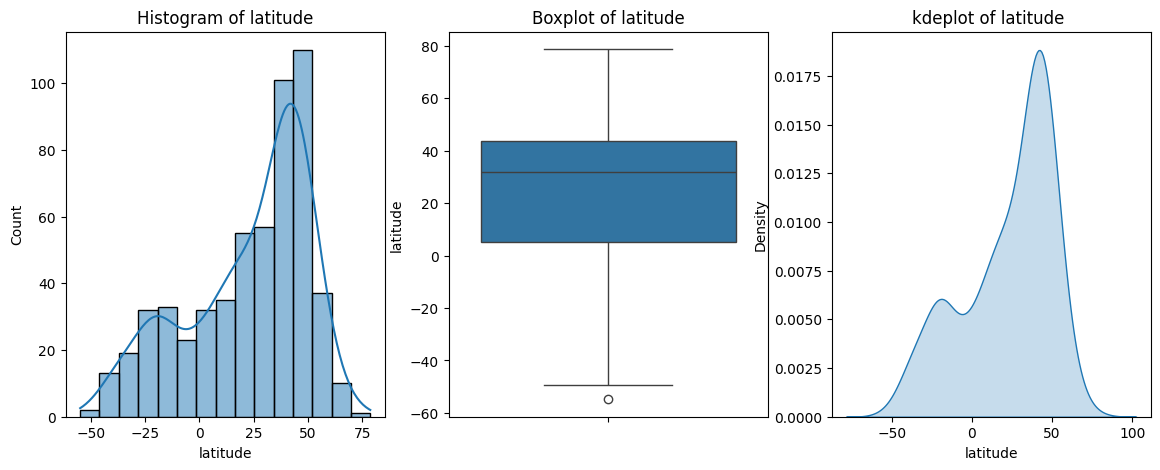

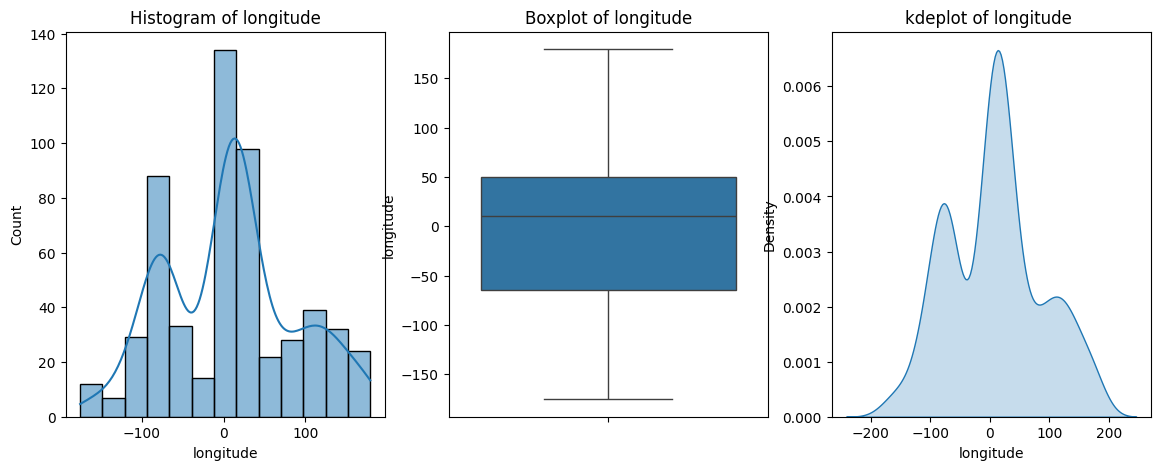

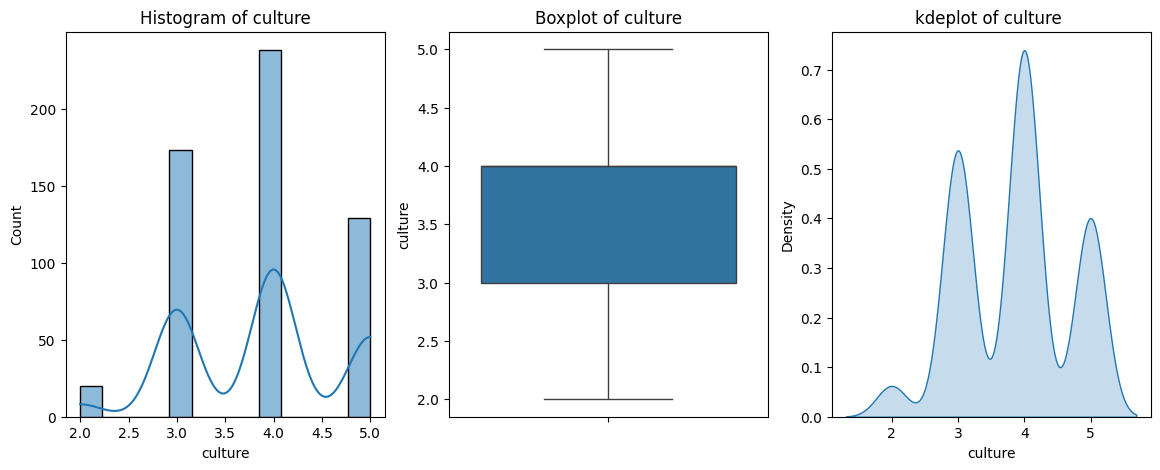

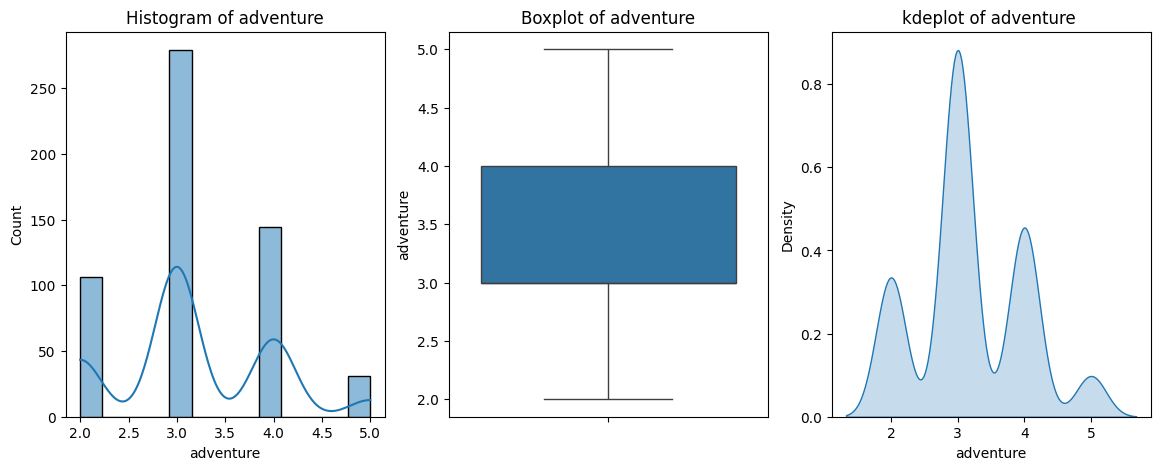

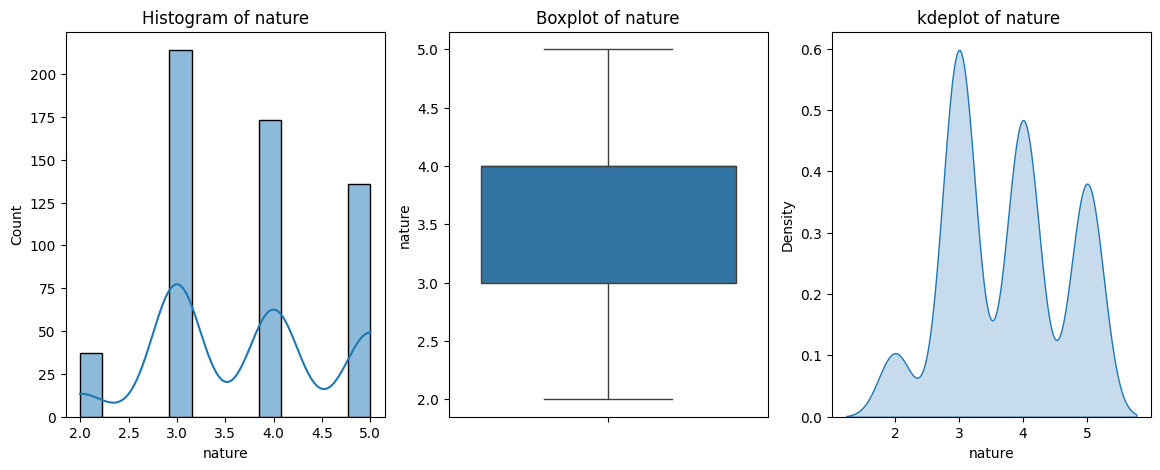

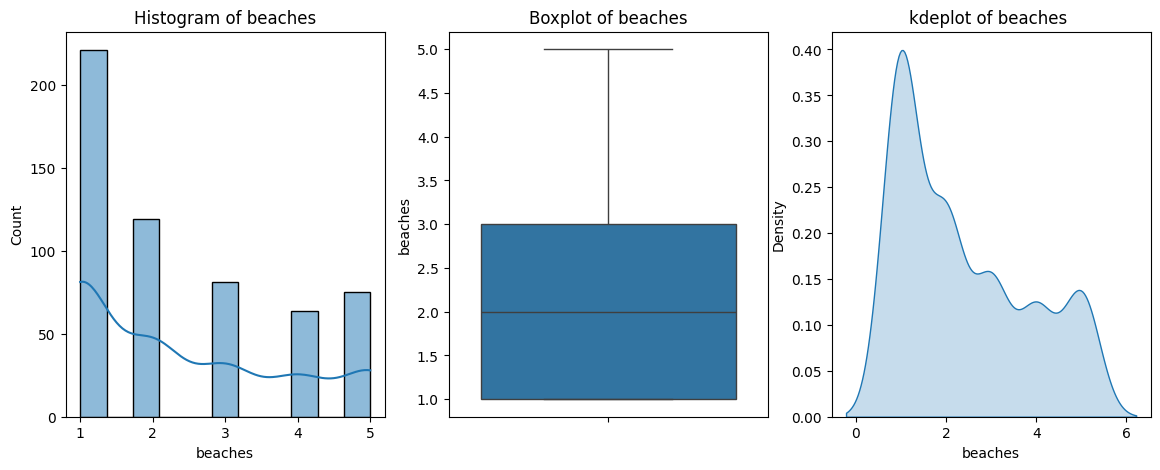

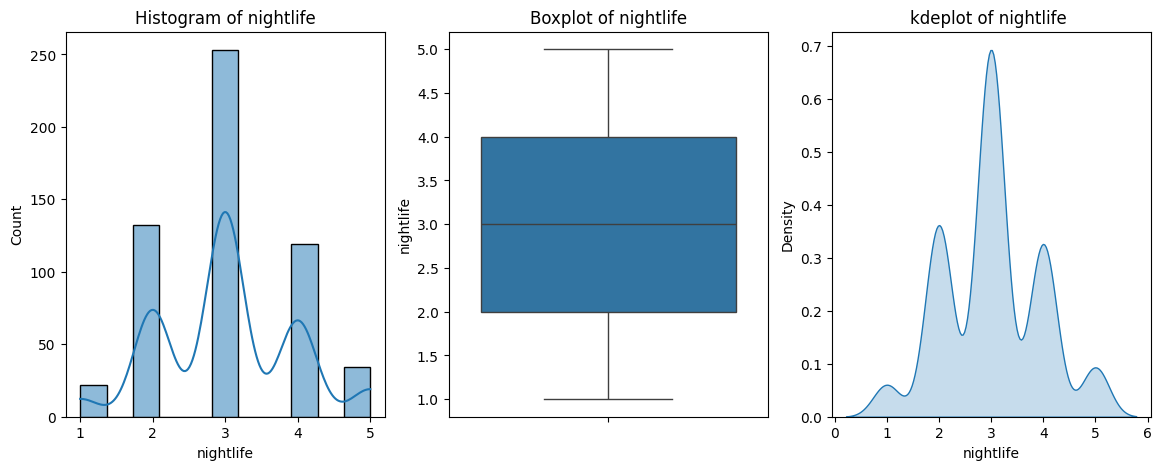

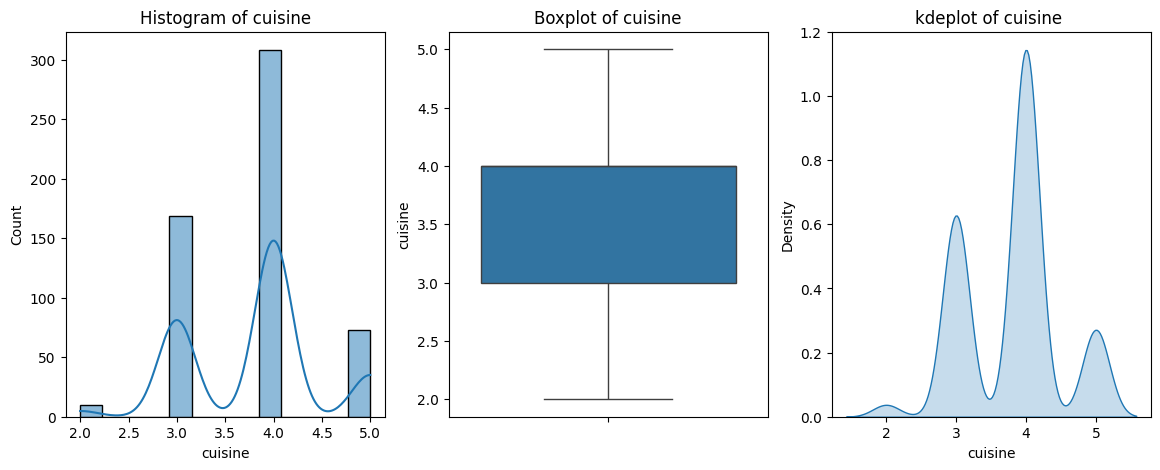

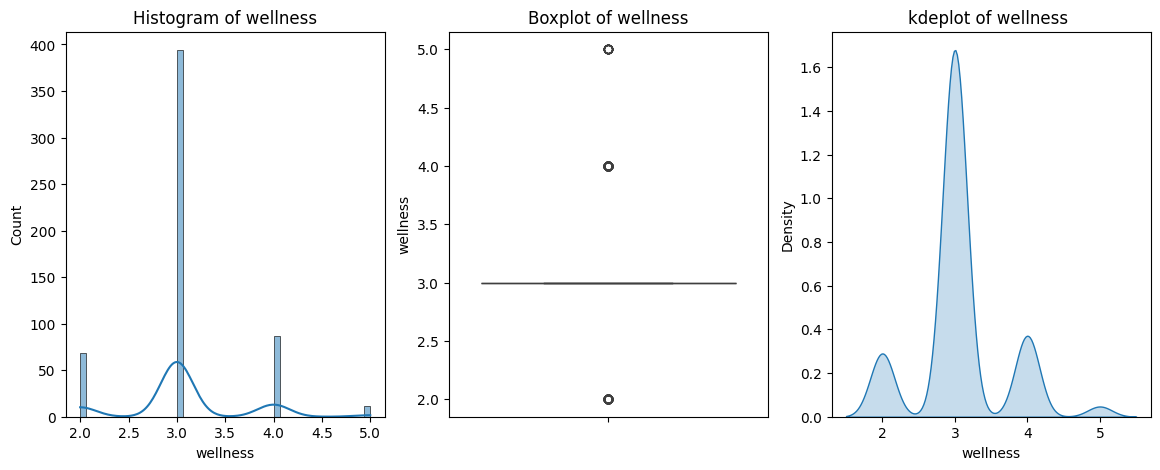

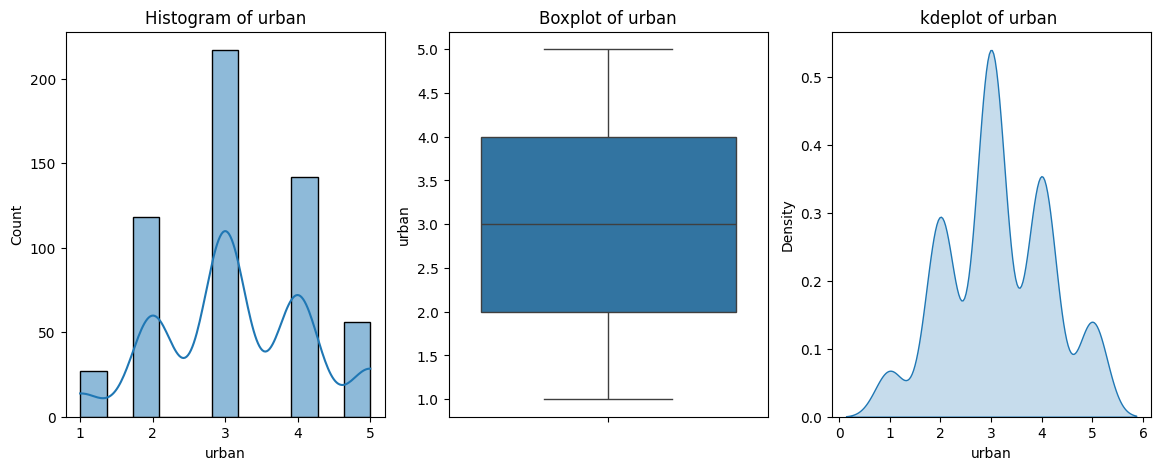

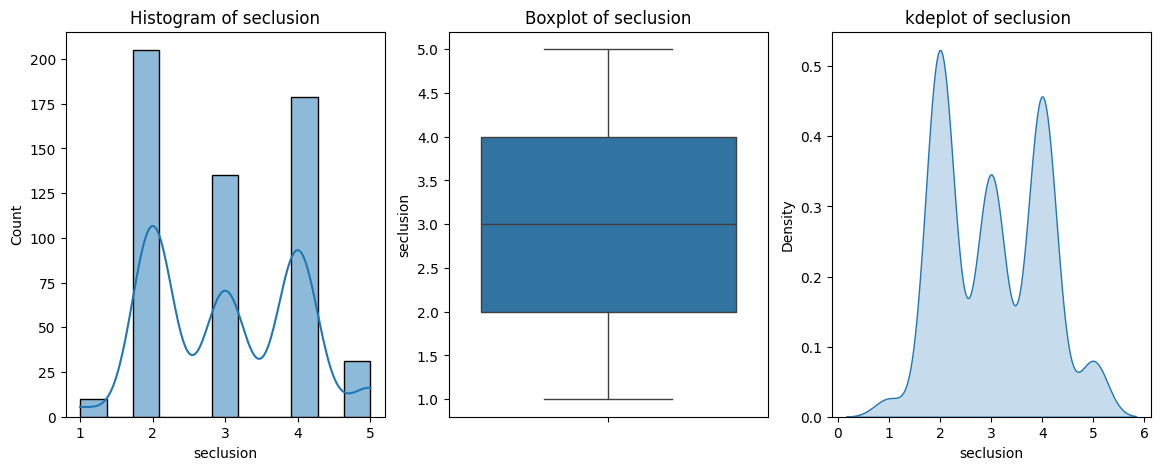

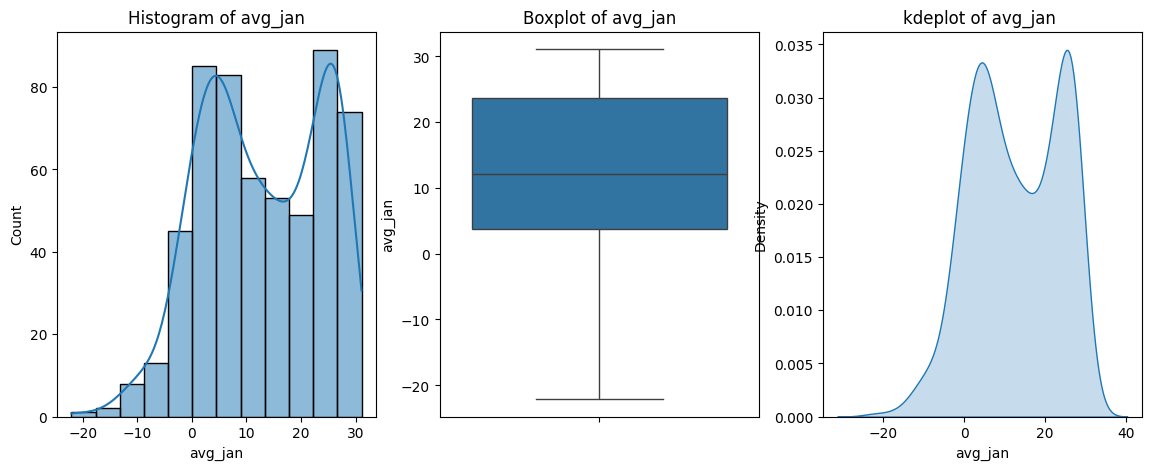

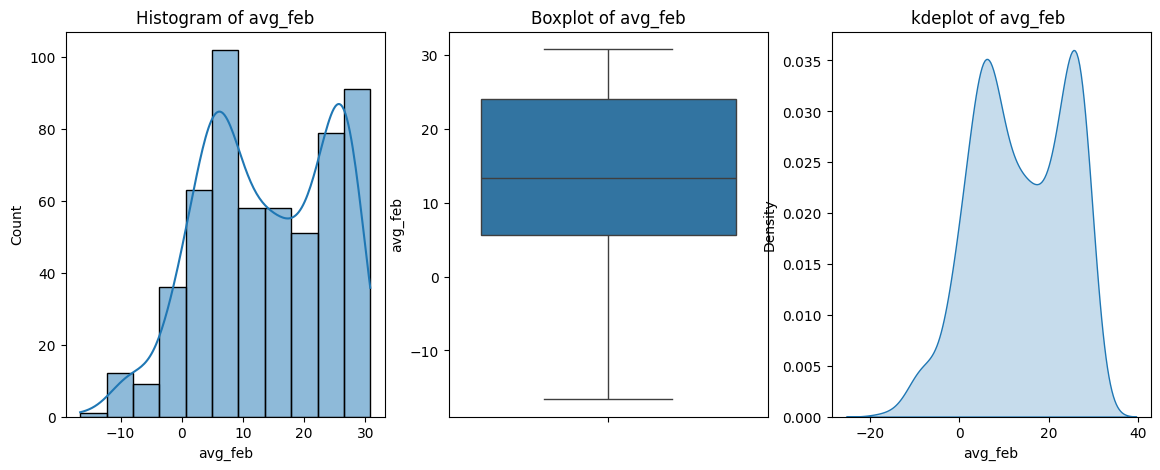

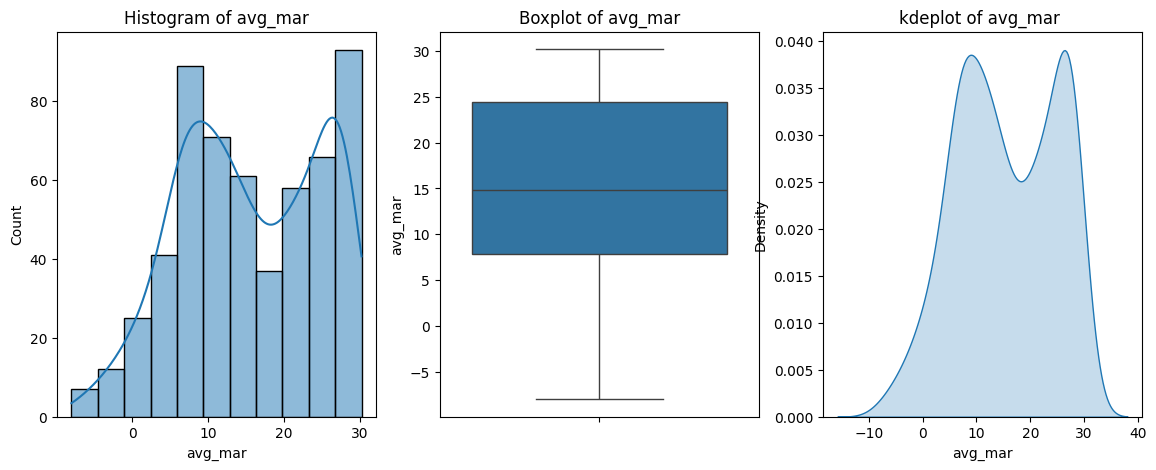

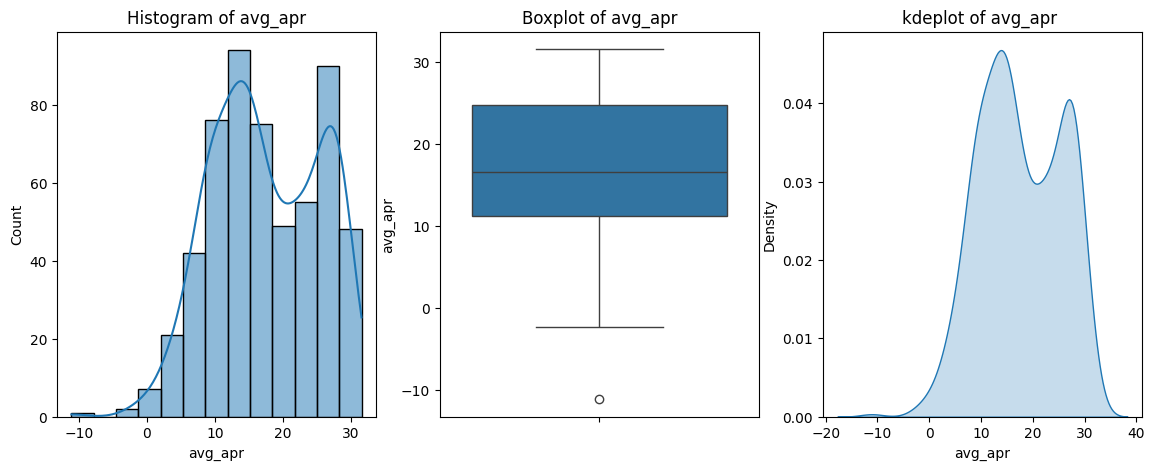

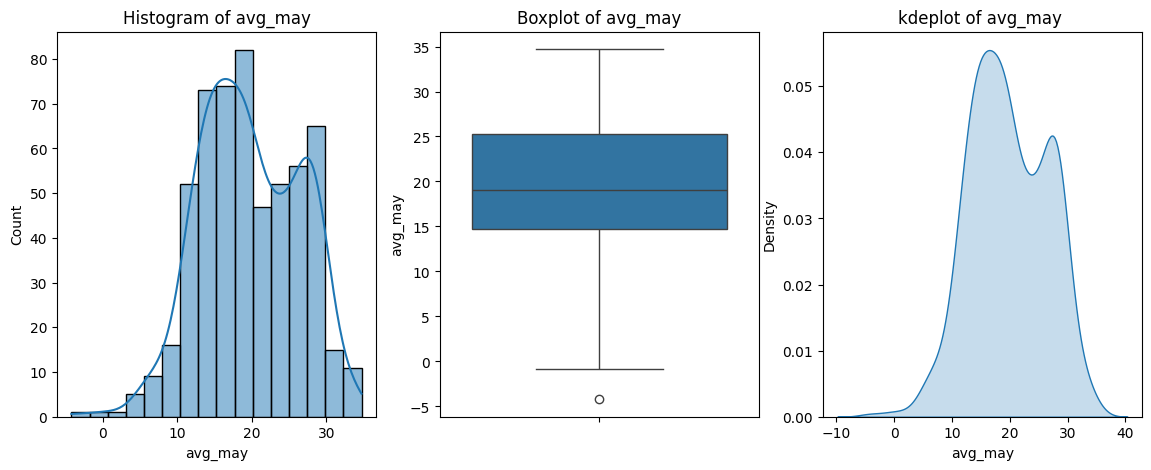

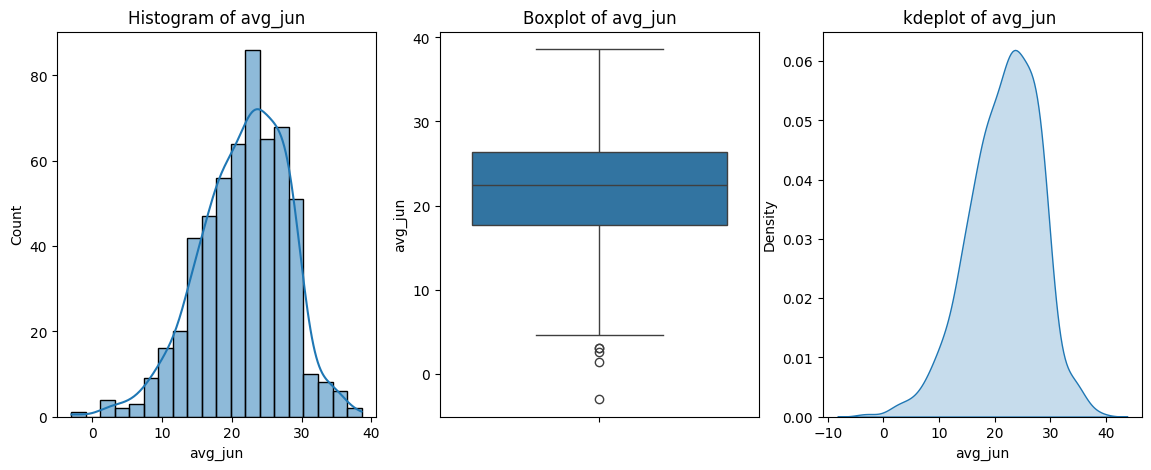

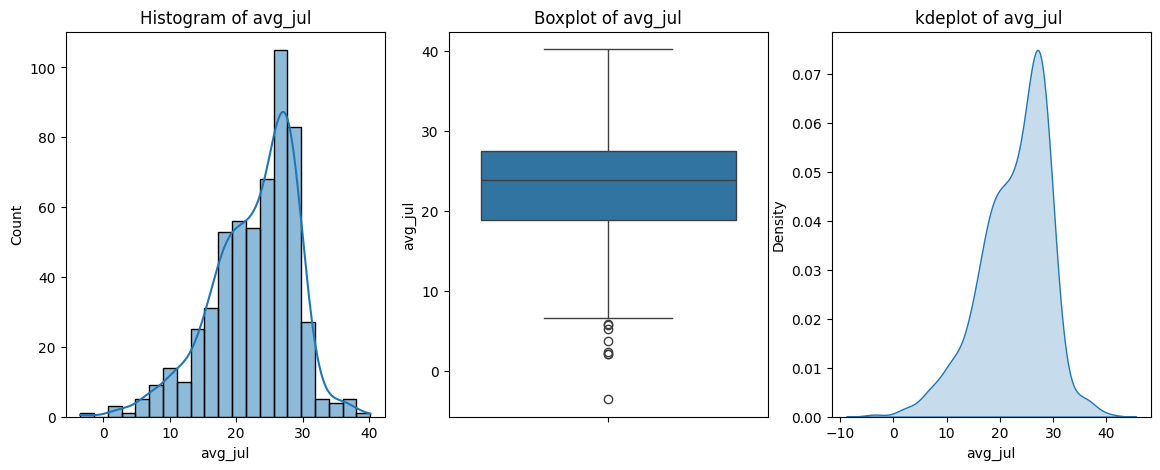

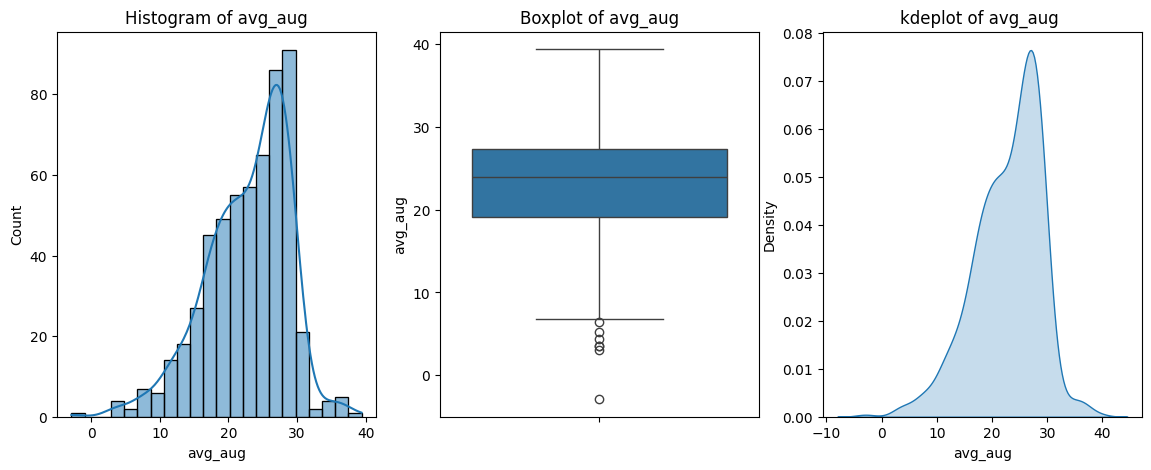

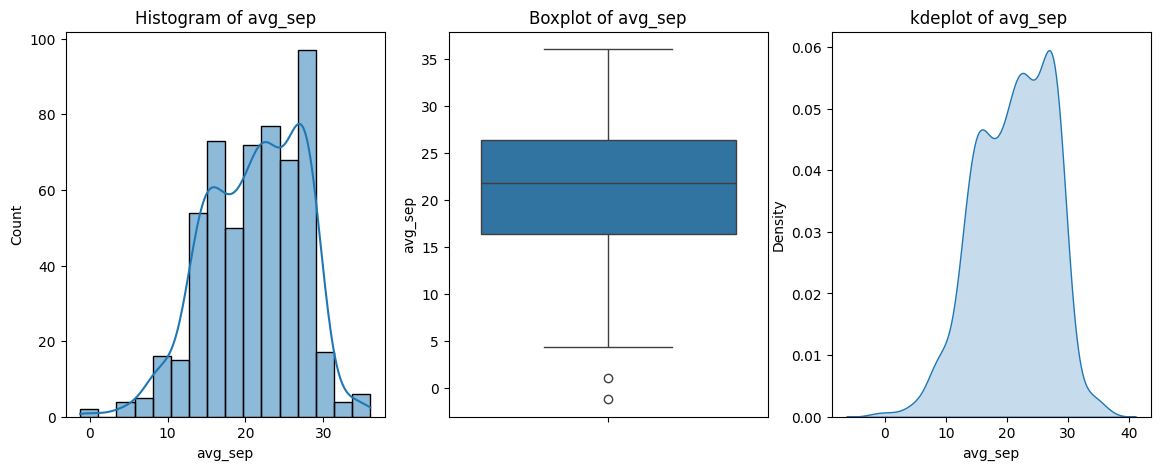

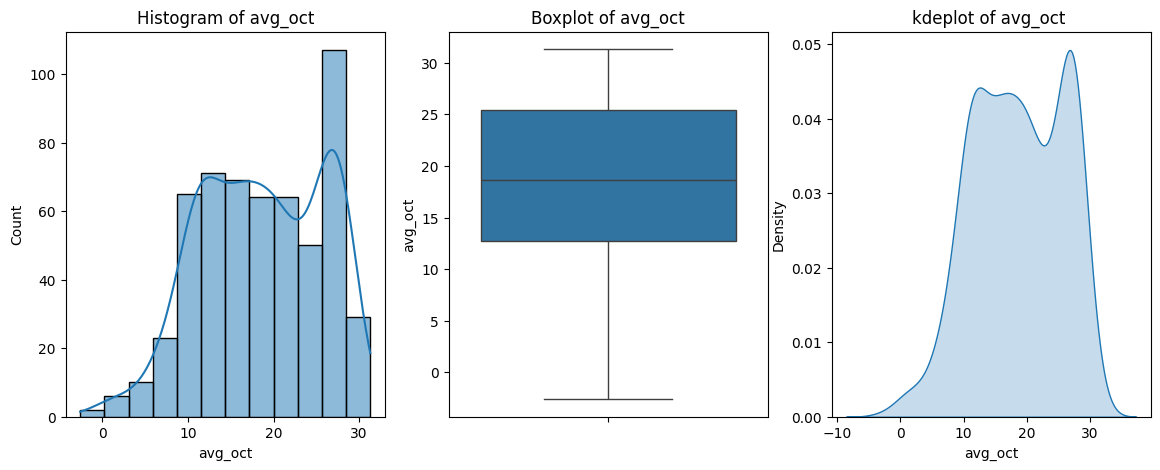

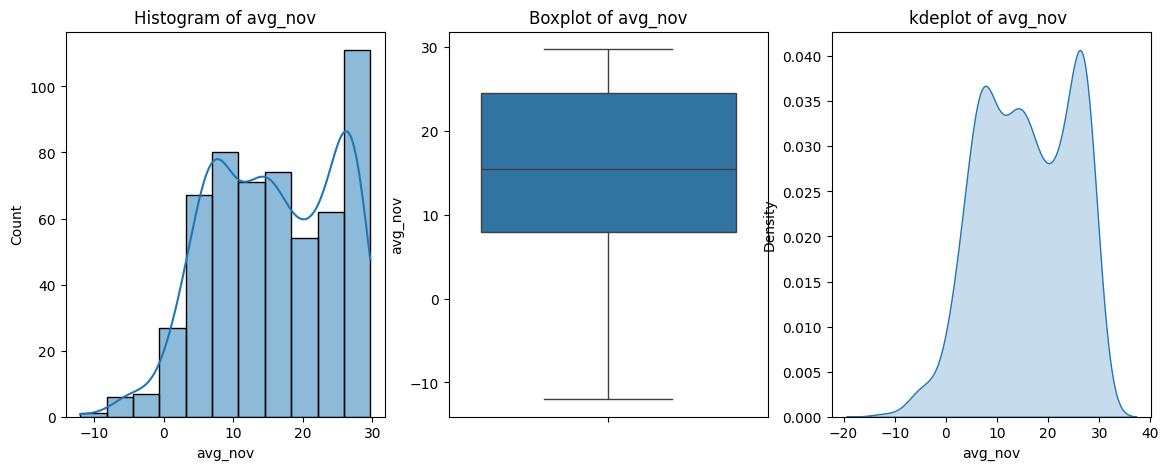

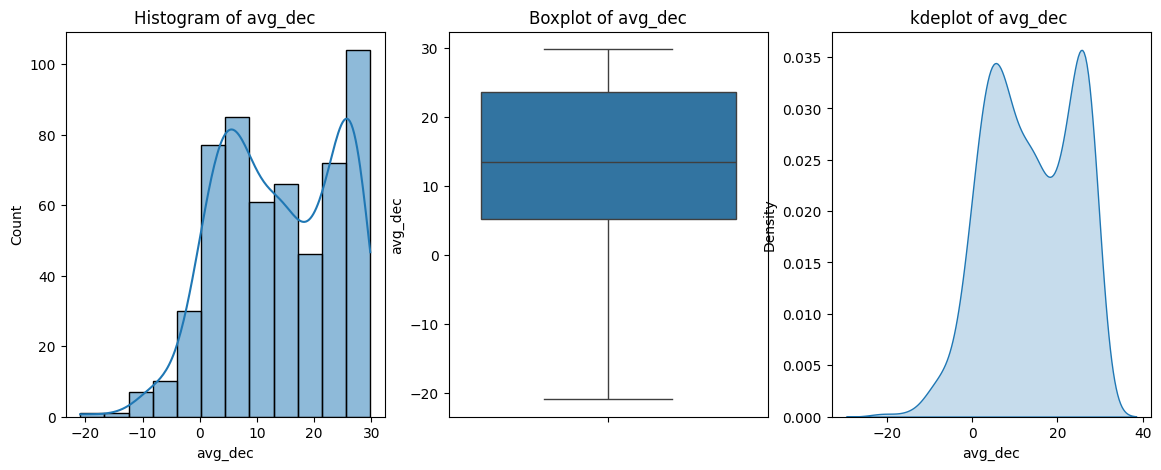

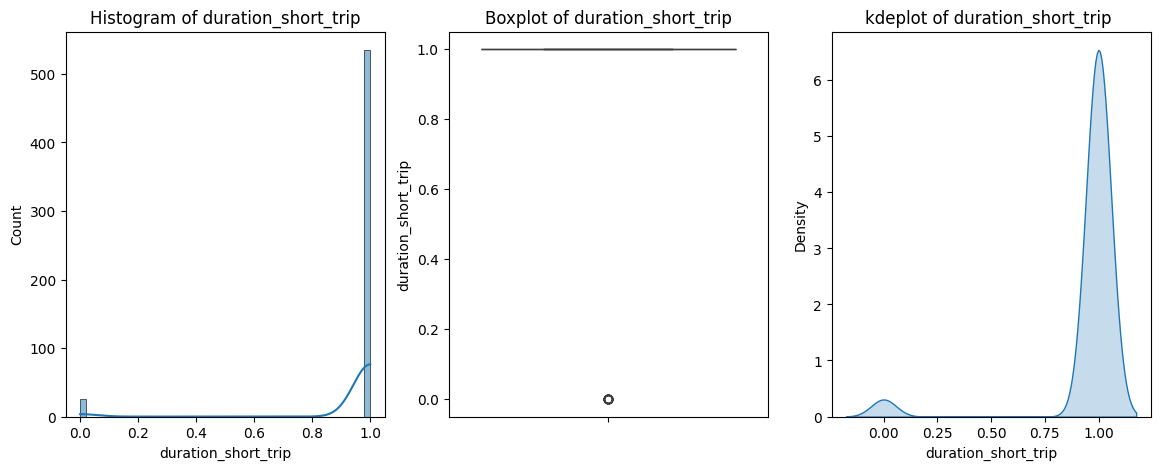

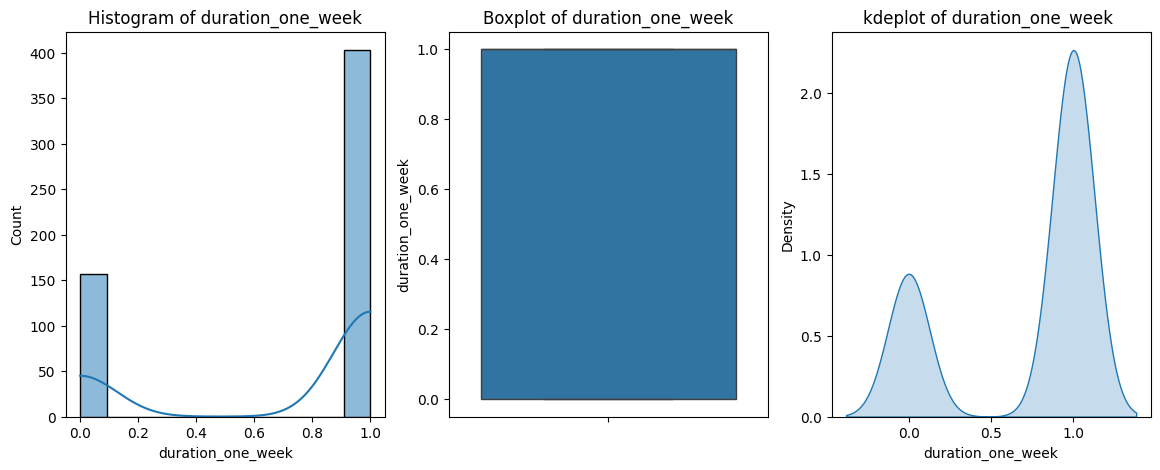

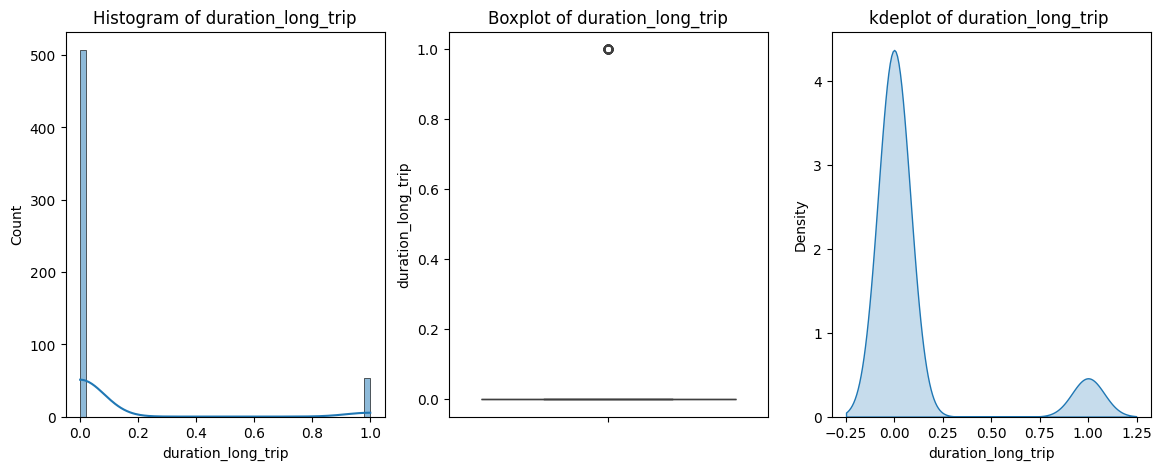

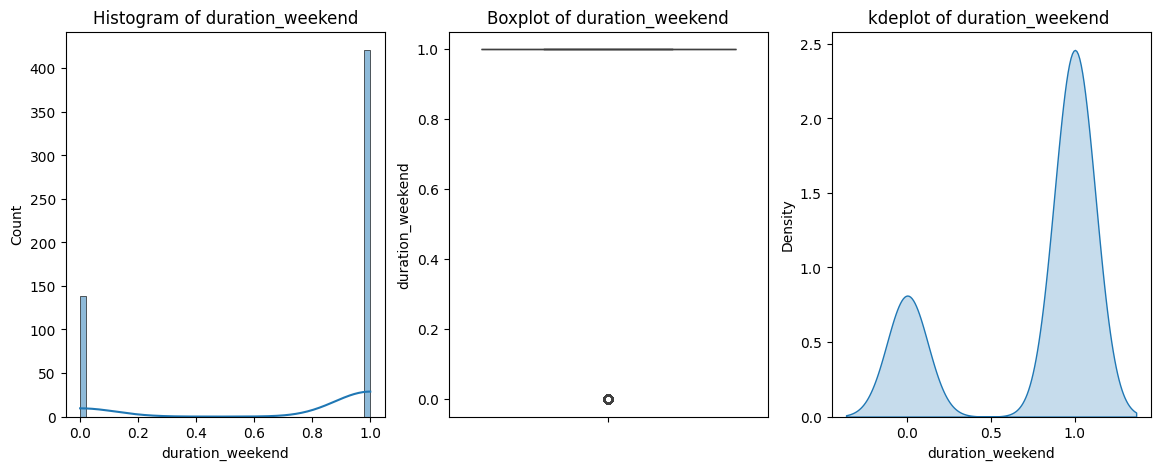

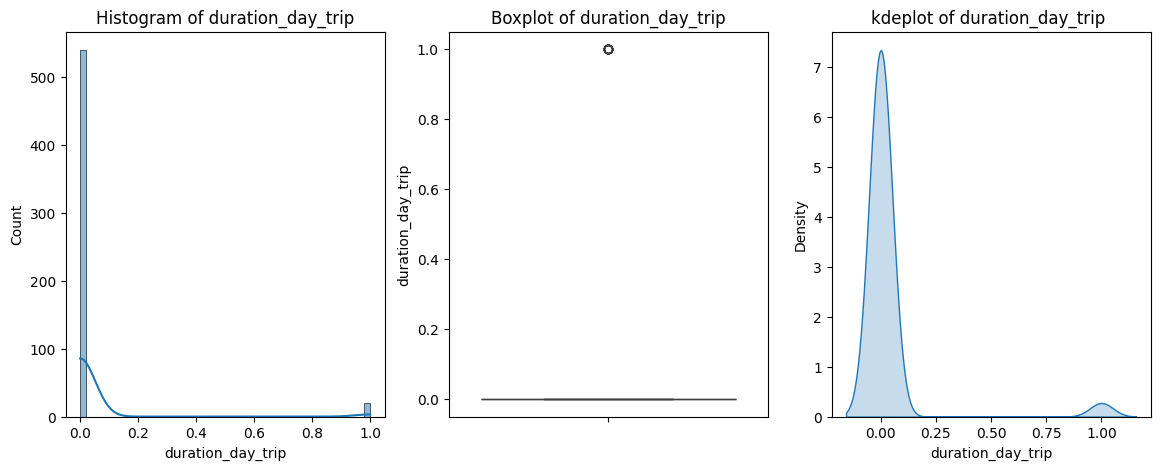

In [116]:
#histogram,boxplot,distribution

for i in Numerical_features:
    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    sns.histplot(df[i],kde=True)
    plt.title(f"Histogram of {i}")

    plt.subplot(1,3,2)
    sns.boxplot(y=df[i])
    plt.title(f"Boxplot of {i}")

    plt.subplot(1,3,3)
    sns.kdeplot(df[i],fill=True)
    plt.title(f"kdeplot of {i} ")

    plt.show()